# 13 Probability Scoring and Calibration

## Purpose

This notebook formalises the probability-scoring analysis for the Hong Kong temperature market example.

The previous discrepancy notebook compared market-implied probabilities, the calendar-threshold baseline classifier and the raw weather-forecast benchmark. This notebook focuses specifically on proper scoring rules and calibration diagnostics.

The main outputs are:

- Brier score;
- log score;
- absolute error;
- Brier skill score relative to a reference model;
- calibration tables;
- reliability-style diagnostics;
- threshold and timing-level score summaries.

The current example is still based on one Hong Kong realised event expanded across forecast timings and thresholds. Therefore, the results should be treated as a pipeline diagnostic rather than final statistical evidence. The same workflow can later be applied to a larger multi-date, multi-city dataset.

## 1. Imports and paths

In [3]:
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROCESSED_DIR = Path("../data/processed/probability_scoring_calibration")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 150)

print("Notebook run time UTC:", datetime.now(timezone.utc).isoformat())
print("Processed directory:", PROCESSED_DIR)

Notebook run time UTC: 2026-06-17T06:34:03.787538+00:00
Processed directory: ../data/processed/probability_scoring_calibration


## 2. Input files

The preferred input is the Step 10 discrepancy table because it already contains the realised label and the probability columns to be scored. If it is not available, the notebook falls back to the Step 9 comparison table.

In [6]:
INPUT_PATHS = {
    "step10_discrepancy": Path("../data/processed/market_model_discrepancy/hong_kong_market_model_probability_discrepancy.csv"),
    "step9_comparison": Path("../data/processed/raw_weather_benchmark/hong_kong_step7_raw_weather_benchmark_comparison.csv"),
    "step7_threshold_dataset": Path("../data/processed/threshold_dataset/hong_kong_threshold_classification_dataset.csv"),
}

for name, path in INPUT_PATHS.items():
    print(f"{name}: {path} | exists={path.exists()}")

step10_discrepancy: ../data/processed/market_model_discrepancy/hong_kong_market_model_probability_discrepancy.csv | exists=True
step9_comparison: ../data/processed/raw_weather_benchmark/hong_kong_step7_raw_weather_benchmark_comparison.csv | exists=True
step7_threshold_dataset: ../data/processed/threshold_dataset/hong_kong_threshold_classification_dataset.csv | exists=True


## 3. Helper functions

In [9]:
def read_csv_if_exists(path):
    path = Path(path)
    if path.exists():
        return pd.read_csv(path)
    return pd.DataFrame()


def clip_probability(series, eps=1e-6):
    return np.clip(pd.to_numeric(series, errors="coerce"), eps, 1 - eps)


def brier_score(y, p):
    y = pd.to_numeric(y, errors="coerce")
    p = pd.to_numeric(p, errors="coerce")
    valid = pd.concat([y, p], axis=1).dropna()
    if valid.empty:
        return np.nan
    return float(np.mean((valid.iloc[:, 1] - valid.iloc[:, 0]) ** 2))


def log_score(y, p, eps=1e-6):
    y = pd.to_numeric(y, errors="coerce")
    p = clip_probability(p, eps=eps)
    valid = pd.DataFrame({"y": y, "p": p}).dropna()
    if valid.empty:
        return np.nan
    return float(np.mean(-(valid["y"] * np.log(valid["p"]) + (1 - valid["y"]) * np.log(1 - valid["p"]))))


def absolute_error(y, p):
    y = pd.to_numeric(y, errors="coerce")
    p = pd.to_numeric(p, errors="coerce")
    valid = pd.concat([y, p], axis=1).dropna()
    if valid.empty:
        return np.nan
    return float(np.mean(np.abs(valid.iloc[:, 1] - valid.iloc[:, 0])))


def classification_accuracy(y, p, threshold=0.5):
    y = pd.to_numeric(y, errors="coerce")
    p = pd.to_numeric(p, errors="coerce")
    valid = pd.DataFrame({"y": y, "p": p}).dropna()
    if valid.empty:
        return np.nan
    return float(np.mean((valid["p"] >= threshold).astype(int) == valid["y"].astype(int)))


def calibration_table(df, probability_col, outcome_col="realised_exceeds_threshold", n_bins=10):
    valid = df[[probability_col, outcome_col]].dropna().copy()

    if valid.empty:
        return pd.DataFrame()

    valid[probability_col] = pd.to_numeric(valid[probability_col], errors="coerce")
    valid[outcome_col] = pd.to_numeric(valid[outcome_col], errors="coerce")
    valid = valid.dropna()

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    labels = [f"[{bins[i]:.1f},{bins[i+1]:.1f})" for i in range(n_bins)]
    labels[-1] = f"[{bins[-2]:.1f},{bins[-1]:.1f}]"

    valid["probability_bin"] = pd.cut(
        valid[probability_col],
        bins=bins,
        labels=labels,
        include_lowest=True,
        right=False,
    )

    # Ensure p=1 is included in the last bin.
    valid.loc[valid[probability_col] == 1.0, "probability_bin"] = labels[-1]

    grouped = (
        valid
        .groupby("probability_bin", observed=False)
        .agg(
            count=(outcome_col, "size"),
            mean_predicted_probability=(probability_col, "mean"),
            realised_event_rate=(outcome_col, "mean"),
        )
        .reset_index()
    )

    grouped["calibration_gap"] = (
        grouped["mean_predicted_probability"] - grouped["realised_event_rate"]
    )
    grouped["absolute_calibration_gap"] = grouped["calibration_gap"].abs()
    grouped["weight"] = grouped["count"] / grouped["count"].sum()

    return grouped


def expected_calibration_error(calib_df):
    if calib_df.empty:
        return np.nan
    valid = calib_df.dropna(subset=["absolute_calibration_gap", "weight"])
    if valid.empty:
        return np.nan
    return float(np.sum(valid["weight"] * valid["absolute_calibration_gap"]))


def max_calibration_error(calib_df):
    if calib_df.empty:
        return np.nan
    valid = calib_df.dropna(subset=["absolute_calibration_gap"])
    if valid.empty:
        return np.nan
    return float(valid["absolute_calibration_gap"].max())


def brier_decomposition_from_bins(df, probability_col, outcome_col="realised_exceeds_threshold", n_bins=10):
    calib = calibration_table(df, probability_col, outcome_col=outcome_col, n_bins=n_bins)

    if calib.empty:
        return {
            "reliability": np.nan,
            "resolution": np.nan,
            "uncertainty": np.nan,
        }

    valid_outcomes = pd.to_numeric(df[outcome_col], errors="coerce").dropna()
    if valid_outcomes.empty:
        return {
            "reliability": np.nan,
            "resolution": np.nan,
            "uncertainty": np.nan,
        }

    base_rate = valid_outcomes.mean()

    reliability = np.sum(
        calib["weight"].fillna(0)
        * (calib["mean_predicted_probability"] - calib["realised_event_rate"]) ** 2
    )

    resolution = np.sum(
        calib["weight"].fillna(0)
        * (calib["realised_event_rate"] - base_rate) ** 2
    )

    uncertainty = base_rate * (1 - base_rate)

    return {
        "reliability": float(reliability),
        "resolution": float(resolution),
        "uncertainty": float(uncertainty),
    }


def evaluate_probability_source(df, source_name, probability_col, outcome_col="realised_exceeds_threshold"):
    valid = df[[outcome_col, probability_col]].dropna().copy()

    if valid.empty:
        return {
            "probability_source": source_name,
            "probability_column": probability_col,
            "rows": 0,
            "brier_score": np.nan,
            "log_score": np.nan,
            "mean_absolute_error": np.nan,
            "classification_accuracy_0_5": np.nan,
            "average_probability": np.nan,
            "realised_event_rate": np.nan,
            "expected_calibration_error": np.nan,
            "max_calibration_error": np.nan,
            "brier_reliability": np.nan,
            "brier_resolution": np.nan,
            "brier_uncertainty": np.nan,
        }

    calib = calibration_table(df, probability_col, outcome_col=outcome_col)
    decomposition = brier_decomposition_from_bins(df, probability_col, outcome_col=outcome_col)

    return {
        "probability_source": source_name,
        "probability_column": probability_col,
        "rows": len(valid),
        "brier_score": brier_score(valid[outcome_col], valid[probability_col]),
        "log_score": log_score(valid[outcome_col], valid[probability_col]),
        "mean_absolute_error": absolute_error(valid[outcome_col], valid[probability_col]),
        "classification_accuracy_0_5": classification_accuracy(valid[outcome_col], valid[probability_col]),
        "average_probability": float(pd.to_numeric(valid[probability_col], errors="coerce").mean()),
        "realised_event_rate": float(pd.to_numeric(valid[outcome_col], errors="coerce").mean()),
        "expected_calibration_error": expected_calibration_error(calib),
        "max_calibration_error": max_calibration_error(calib),
        "brier_reliability": decomposition["reliability"],
        "brier_resolution": decomposition["resolution"],
        "brier_uncertainty": decomposition["uncertainty"],
    }

## 4. Load scoring dataset

In [12]:
scoring_df = read_csv_if_exists(INPUT_PATHS["step10_discrepancy"])
input_source = "step10_discrepancy"

if scoring_df.empty:
    scoring_df = read_csv_if_exists(INPUT_PATHS["step9_comparison"])
    input_source = "step9_comparison"

if scoring_df.empty:
    scoring_df = read_csv_if_exists(INPUT_PATHS["step7_threshold_dataset"])
    input_source = "step7_threshold_dataset"

if scoring_df.empty:
    raise FileNotFoundError(
        "No suitable input dataset found. Run Notebooks 9, 11 and 12 before this notebook."
    )

print("Input source:", input_source)
print("Scoring dataset shape:", scoring_df.shape)
display(scoring_df.head())

Input source: step10_discrepancy
Scoring dataset shape: (40, 54)


,contract_slug,city,target_local_date,settlement_source,settlement_variable,official_realised_temperature_c,threshold_c,realised_exceeds_threshold,forecast_model,forecast_run_time_utc,forecast_issue_time_utc,forecast_valid_time_utc,timing_label,forecast_timing_category,lead_time_to_valid_hours,lead_time_to_day_start_hours,lead_time_to_day_midpoint_hours,lead_time_to_day_end_hours,market_implied_threshold_prob_raw,market_implied_threshold_prob_normalised,number_of_contributing_bins,average_price_time_gap_minutes,market_price_timestamp_rule,forecast_temperature_c,forecast_temperature_source,forecast_feature_status,lead_time_days_previous_run,raw_forecast_daily_max_c,raw_forecast_error_c,raw_forecast_margin_to_threshold_c,raw_forecast_threshold_probability,benchmark_type,baseline_classifier_probability,baseline_model_name,raw_forecast_brier_component,market_brier_component,baseline_brier_component,market_error,market_abs_error,market_log_score_component,baseline_classifier_error,baseline_classifier_abs_error,baseline_classifier_brier_component,baseline_classifier_log_score_component,raw_weather_error,raw_weather_abs_error,raw_weather_brier_component,raw_weather_log_score_component,baseline_minus_market_probability,abs_baseline_minus_market_probability,raw_minus_market_probability,abs_raw_minus_market_probability,raw_minus_baseline_probability,abs_raw_minus_baseline_probability
0,highest-temperature-in-hong-kong-on-may-30-2026,Hong Kong,2026-05-30,Hong Kong Observatory,Daily Maximum Temperature,32.6,24.0,1,AIFS_or_ECMWF_example,2026-05-28 12:00:00+00:00,2026-05-28 12:00:00+00:00,2026-05-30 12:00:00+00:00,two_day_valid_time_example,full_day_ex_ante,48.0,28.0,40.0,51.999722,0.9645,0.998964,10,0.1,first available Polymarket price at or after f...,NaN,not_attached_in_step_7,pending_ai_weather_feature_merge,2,30.5,-2.1,6.5,1.0,deterministic_raw_point_forecast,0.992736,logistic_regression_calendar_threshold_baseline,0.0,0.000001,0.000053,-0.001036,0.001036,0.001036,-0.007264,0.007264,0.000053,0.007291,0.0,0.0,0.0,0.000001,-0.006229,0.006229,0.001036,0.001036,0.007264,0.007264
1,highest-temperature-in-hong-kong-on-may-30-2026,Hong Kong,2026-05-30,Hong Kong Observatory,Daily Maximum Temperature,32.6,25.0,1,AIFS_or_ECMWF_example,2026-05-28 12:00:00+00:00,2026-05-28 12:00:00+00:00,2026-05-30 12:00:00+00:00,two_day_valid_time_example,full_day_ex_ante,48.0,28.0,40.0,51.999722,0.9620,0.996375,9,0.1,first available Polymarket price at or after f...,NaN,not_attached_in_step_7,pending_ai_weather_feature_merge,2,30.5,-2.1,5.5,1.0,deterministic_raw_point_forecast,0.984324,logistic_regression_calendar_threshold_baseline,0.0,0.000013,0.000246,-0.003625,0.003625,0.003632,-0.015676,0.015676,0.000246,0.015800,0.0,0.0,0.0,0.000001,-0.012050,0.012050,0.003625,0.003625,0.015676,0.015676
2,highest-temperature-in-hong-kong-on-may-30-2026,Hong Kong,2026-05-30,Hong Kong Observatory,Daily Maximum Temperature,32.6,26.0,1,AIFS_or_ECMWF_example,2026-05-28 12:00:00+00:00,2026-05-28 12:00:00+00:00,2026-05-30 12:00:00+00:00,two_day_valid_time_example,full_day_ex_ante,48.0,28.0,40.0,51.999722,0.9595,0.993786,8,0.1,first available Polymarket price at or after f...,NaN,not_attached_in_step_7,pending_ai_weather_feature_merge,2,30.5,-2.1,4.5,1.0,deterministic_raw_point_forecast,0.966503,logistic_regression_calendar_threshold_baseline,0.0,0.000039,0.001122,-0.006214,0.006214,0.006234,-0.033497,0.033497,0.001122,0.034071,0.0,0.0,0.0,0.000001,-0.027283,0.027283,0.006214,0.006214,0.033497,0.033497
3,highest-temperature-in-hong-kong-on-may-30-2026,Hong Kong,2026-05-30,Hong Kong Observatory,Daily Maximum Temperature,32.6,27.0,1,AIFS_or_ECMWF_example,2026-05-28 12:00:00+00:00,2026-05-28 12:00:00+00:00,2026-05-30 12:00:00+00:00,two_day_valid_time_example,full_day_ex_ante,48.0,28.0,40.0,51.999722,0.9540,0.988089,7,0.1,first available Polymarket price at or after f...,NaN,not_attached_in_step_7,pending_ai_weather_feature_merge,2,30.5,-2.1,3.5,1.0,deterministic_raw_point_forecast,0.

## 5. Identify probability sources

In [15]:
required_columns = [
    "realised_exceeds_threshold",
    "market_implied_threshold_prob_normalised",
]

missing = [c for c in required_columns if c not in scoring_df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

candidate_probability_sources = {
    "market_implied_probability": "market_implied_threshold_prob_normalised",
    "calendar_threshold_baseline": "baseline_classifier_probability",
    "raw_weather_benchmark": "raw_forecast_threshold_probability",
}

available_sources = {
    source: col
    for source, col in candidate_probability_sources.items()
    if col in scoring_df.columns and scoring_df[col].notna().any()
}

print("Available sources:")
for source, col in available_sources.items():
    print(f"- {source}: {col}")

scoring_df[["timing_label", "threshold_c", "realised_exceeds_threshold"] + list(available_sources.values())].head(20)

Available sources:
- market_implied_probability: market_implied_threshold_prob_normalised
- calendar_threshold_baseline: baseline_classifier_probability
- raw_weather_benchmark: raw_forecast_threshold_probability


,timing_label,threshold_c,realised_exceeds_threshold,market_implied_threshold_prob_normalised,baseline_classifier_probability,raw_forecast_threshold_probability
0,two_day_valid_time_example,24.0,1,0.998964,0.992736,1.0
1,two_day_valid_time_example,25.0,1,0.996375,0.984324,1.0
2,two_day_valid_time_example,26.0,1,0.993786,0.966503,1.0
3,two_day_valid_time_example,27.0,1,0.988089,0.929862,1.0
4,two_day_valid_time_example,28.0,1,0.984464,0.858992,1.0
5,two_day_valid_time_example,29.0,1,0.948213,0.736781,1.0
6,two_day_valid_time_example,30.0,1,0.901088,0.562586,1.0
7,two_day_valid_time_example,31.0,1,0.730192,0.371456,0.0
8,two_day_valid_time_example,32.0,1,0.403936,0.213558,0.0
9,two_day_valid_time_example,33.0,0,0.191611,0.110933,0.0


## 6. Overall proper scoring metrics

Brier score and log score are proper scoring rules. A lower value indicates better probabilistic performance.

For this single-event prototype, the results are diagnostic. They should become more meaningful once the same workflow is applied across more dates, cities and thresholds.

In [18]:
score_rows = []

for source, col in available_sources.items():
    score_rows.append(
        evaluate_probability_source(scoring_df, source, col)
    )

scores_df = pd.DataFrame(score_rows).sort_values("brier_score").reset_index(drop=True)

# Brier skill score relative to the calendar-threshold baseline if available.
if "calendar_threshold_baseline" in scores_df["probability_source"].values:
    reference_brier = scores_df.loc[
        scores_df["probability_source"] == "calendar_threshold_baseline",
        "brier_score",
    ].iloc[0]

    scores_df["brier_skill_vs_calendar_baseline"] = (
        1 - scores_df["brier_score"] / reference_brier
    )
else:
    reference_brier = scores_df["brier_score"].max()
    scores_df["brier_skill_vs_worst_available"] = (
        1 - scores_df["brier_score"] / reference_brier
    )

scores_df

,probability_source,probability_column,rows,brier_score,log_score,mean_absolute_error,classification_accuracy_0_5,average_probability,realised_event_rate,expected_calibration_error,max_calibration_error,brier_reliability,brier_resolution,brier_uncertainty,brier_skill_vs_calendar_baseline
0,market_implied_probability,market_implied_threshold_prob_normalised,40,0.052922,0.162932,0.115390,0.900,0.808516,0.9,0.115390,0.711816,0.052319,0.090000,0.09,0.596849
1,calendar_threshold_baseline,baseline_classifier_probability,40,0.131270,0.381431,0.249414,0.800,0.672773,0.9,0.249414,0.786442,0.131037,0.090000,0.09,0.000000
2,raw_weather_benchmark,raw_forecast_threshold_probability,40,0.225000,3.108491,0.225000,0.775,0.675000,0.9,0.225000,0.692308,0.155769,0.020769,0.09,-0.714020


## 7. Calibration tables

The reliability-style tables compare average predicted probability with realised event frequency inside probability bins.

With only 40 rows in the current example, these tables are mainly a sanity check. A larger sample will be needed for formal calibration claims.

In [21]:
calibration_tables = {}

for source, col in available_sources.items():
    calib = calibration_table(scoring_df, col, n_bins=10)
    calib.insert(0, "probability_source", source)
    calib.insert(1, "probability_column", col)
    calibration_tables[source] = calib

calibration_df = pd.concat(calibration_tables.values(), ignore_index=True) if calibration_tables else pd.DataFrame()
calibration_df

,probability_source,probability_column,probability_bin,count,mean_predicted_probability,realised_event_rate,calibration_gap,absolute_calibration_gap,weight
0,market_implied_probability,market_implied_threshold_prob_normalised,"[0.0,0.1)",2,0.085837,0.000000,0.085837,0.085837,0.050
1,market_implied_probability,market_implied_threshold_prob_normalised,"[0.1,0.2)",2,0.153222,0.000000,0.153222,0.153222,0.050
2,market_implied_probability,market_implied_threshold_prob_normalised,"[0.2,0.3)",1,0.288184,1.000000,-0.711816,0.711816,0.025
3,market_implied_probability,market_implied_threshold_prob_normalised,"[0.3,0.4)",2,0.344853,1.000000,-0.655147,0.655147,0.050
4,market_implied_probability,market_implied_threshold_prob_normalised,"[0.4,0.5)",1,0.403936,1.000000,-0.596064,0.596064,0.025
5,market_implied_probability,market_implied_threshold_prob_normalised,"[0.5,0.6)",0,NaN,NaN,NaN,NaN,0.000
6,market_implied_probability,market_implied_threshold_prob_normalised,"[0.6,0.7)",0,NaN,NaN,NaN,NaN,0.000
7,market_implied_probability,market_implied_threshold_prob_normalised,"[0.7,0.8)",4,0.724095,1.000000,-0.275905,0.275905,0.100
8,market_implied_probability,market_implied_threshold_prob_normalised,"[0.8,0.9)",0,NaN,NaN,NaN,NaN,0.000
9,market_implied_probability,market_implied_threshold_prob_normalised,"[0.9,1.0]",28,0.985154,1.000000,-0.014846,0.014846,0.700


## 8. Reliability-style plots

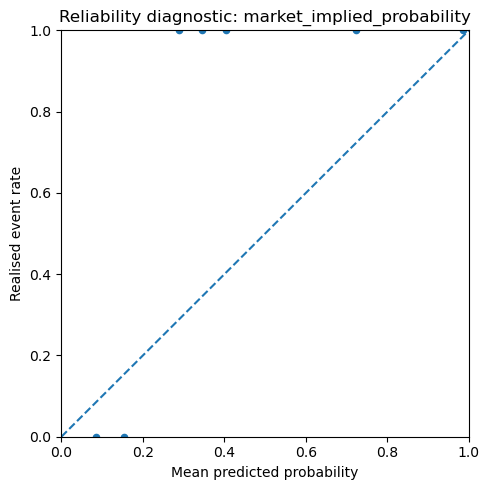

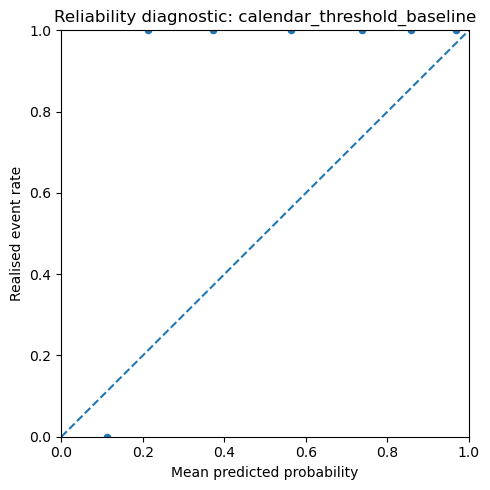

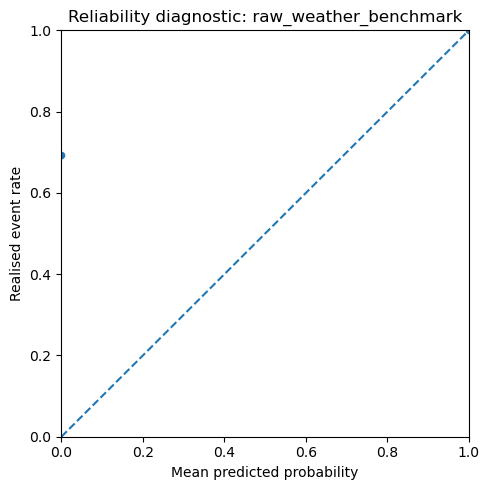

In [24]:
for source, calib in calibration_tables.items():
    valid = calib[calib["count"] > 0].copy()

    if valid.empty:
        continue

    ax = valid.plot(
        x="mean_predicted_probability",
        y="realised_event_rate",
        kind="scatter",
        figsize=(5, 5),
        title=f"Reliability diagnostic: {source}",
    )

    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Realised event rate")
    plt.tight_layout()
    plt.show()

## 9. Score summaries by threshold

This view shows whether a probability source performs better or worse around particular thresholds.

In [27]:
threshold_score_rows = []

for threshold_c, group in scoring_df.groupby("threshold_c", dropna=False):
    for source, col in available_sources.items():
        threshold_score_rows.append({
            "threshold_c": threshold_c,
            "probability_source": source,
            "rows": group[[col, "realised_exceeds_threshold"]].dropna().shape[0],
            "event_rate": pd.to_numeric(group["realised_exceeds_threshold"], errors="coerce").mean(),
            "average_probability": pd.to_numeric(group[col], errors="coerce").mean(),
            "brier_score": brier_score(group["realised_exceeds_threshold"], group[col]),
            "log_score": log_score(group["realised_exceeds_threshold"], group[col]),
            "mean_absolute_error": absolute_error(group["realised_exceeds_threshold"], group[col]),
        })

threshold_scores_df = pd.DataFrame(threshold_score_rows)
threshold_scores_df

,threshold_c,probability_source,rows,event_rate,average_probability,brier_score,log_score,mean_absolute_error
0,24.0,market_implied_probability,4,1.0,0.999383,4.390335e-07,0.000617,0.000617
1,24.0,calendar_threshold_baseline,4,1.0,0.992736,5.276999e-05,0.007291,0.007264
2,24.0,raw_weather_benchmark,4,1.0,1.000000,0.000000e+00,0.000001,0.000000
3,25.0,market_implied_probability,4,1.0,0.998378,3.968665e-06,0.001624,0.001622
4,25.0,calendar_threshold_baseline,4,1.0,0.984324,2.457221e-04,0.015800,0.015676
5,25.0,raw_weather_benchmark,4,1.0,1.000000,0.000000e+00,0.000001,0.000000
6,26.0,market_implied_probability,4,1.0,0.997373,1.119231e-05,0.002633,0.002627
7,26.0,calendar_threshold_baseline,4,1.0,0.966503,1.122075e-03,0.034071,0.033497
8,26.0,raw_weather_benchmark,4,1.0,1.000000,0.000000e+00,0.000001,0.000000
9,27.0,market_implied_probability,4,1.0,0.995233,3.984924e-05,0.004787,0.004767


probability_source,threshold_c,calendar_threshold_baseline,market_implied_probability,raw_weather_benchmark
0,24.0,0.000053,4.390335e-07,0.00
1,25.0,0.000246,3.968665e-06,0.00
2,26.0,0.001122,1.119231e-05,0.00
3,27.0,0.004919,3.984924e-05,0.00
4,28.0,0.019883,6.916060e-05,0.00
5,29.0,0.069284,7.670688e-04,0.00
6,30.0,0.191331,5.277962e-03,0.50
7,31.0,0.395067,7.672253e-02,0.75
8,32.0,0.618492,4.301516e-01,1.00
9,33.0,0.012306,1.617400e-02,0.00


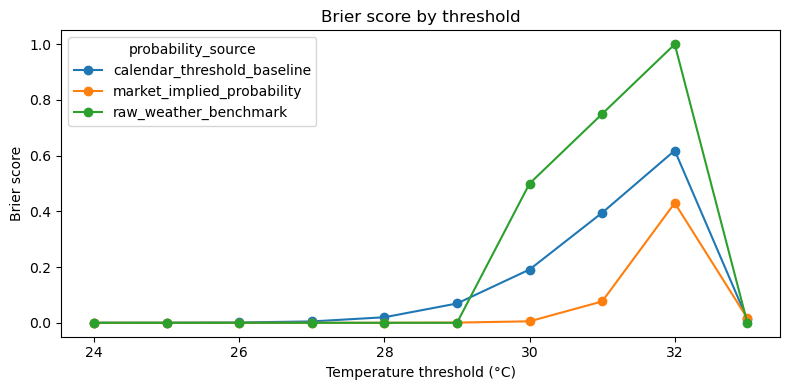

In [29]:
if not threshold_scores_df.empty:
    threshold_pivot_brier = threshold_scores_df.pivot(
        index="threshold_c",
        columns="probability_source",
        values="brier_score",
    ).reset_index()

    display(threshold_pivot_brier)

    ax = threshold_pivot_brier.plot(
        x="threshold_c",
        figsize=(8, 4),
        marker="o",
        title="Brier score by threshold",
    )
    ax.set_xlabel("Temperature threshold (°C)")
    ax.set_ylabel("Brier score")
    plt.tight_layout()
    plt.show()

## 10. Score summaries by forecast timing

This view checks whether score behaviour changes across forecast issue times and full-day versus within-day forecasts.

In [32]:
timing_group_cols = [c for c in ["timing_label", "forecast_timing_category"] if c in scoring_df.columns]

timing_score_rows = []

if timing_group_cols:
    for group_key, group in scoring_df.groupby(timing_group_cols, dropna=False):
        if not isinstance(group_key, tuple):
            group_key = (group_key,)

        base_row = dict(zip(timing_group_cols, group_key))

        for source, col in available_sources.items():
            row = base_row.copy()
            row.update({
                "probability_source": source,
                "rows": group[[col, "realised_exceeds_threshold"]].dropna().shape[0],
                "event_rate": pd.to_numeric(group["realised_exceeds_threshold"], errors="coerce").mean(),
                "average_probability": pd.to_numeric(group[col], errors="coerce").mean(),
                "brier_score": brier_score(group["realised_exceeds_threshold"], group[col]),
                "log_score": log_score(group["realised_exceeds_threshold"], group[col]),
                "mean_absolute_error": absolute_error(group["realised_exceeds_threshold"], group[col]),
            })
            timing_score_rows.append(row)

timing_scores_df = pd.DataFrame(timing_score_rows)
timing_scores_df

,timing_label,forecast_timing_category,probability_source,rows,event_rate,average_probability,brier_score,log_score,mean_absolute_error
0,one_and_half_day_valid_time_example,full_day_ex_ante,market_implied_probability,10,0.9,0.807321,0.054661,0.164922,0.115646
1,one_and_half_day_valid_time_example,full_day_ex_ante,calendar_threshold_baseline,10,0.9,0.672773,0.131270,0.381431,0.249414
2,one_and_half_day_valid_time_example,full_day_ex_ante,raw_weather_benchmark,10,0.9,0.600000,0.300000,4.144654,0.300000
3,one_day_valid_time_example,full_day_ex_ante,market_implied_probability,10,0.9,0.815184,0.048059,0.143788,0.100899
4,one_day_valid_time_example,full_day_ex_ante,calendar_threshold_baseline,10,0.9,0.672773,0.131270,0.381431,0.249414
5,one_day_valid_time_example,full_day_ex_ante,raw_weather_benchmark,10,0.9,0.600000,0.300000,4.144654,0.300000
6,same_day_valid_time_example,within_day_update,market_implied_probability,10,0.9,0.797887,0.061197,0.180066,0.120365
7,same_day_valid_time_example,within_day_update,calendar_threshold_baseline,10,0.9,0.672773,0.131270,0.381431,0.249414
8,same_day_valid_time_example,within_day_update,raw_weather_benchmark,10,0.9,0.800000,0.100000,1.381552,0.100000
9,two_day_valid_time_example,full_day_ex_ante,market_implied_probability,10,0.9,0.813672,0.047771,0.162953,0.124650


probability_source,timing_label,calendar_threshold_baseline,market_implied_probability,raw_weather_benchmark
0,one_and_half_day_valid_time_example,0.13127,0.054661,0.3
1,one_day_valid_time_example,0.13127,0.048059,0.3
2,same_day_valid_time_example,0.13127,0.061197,0.1
3,two_day_valid_time_example,0.13127,0.047771,0.2


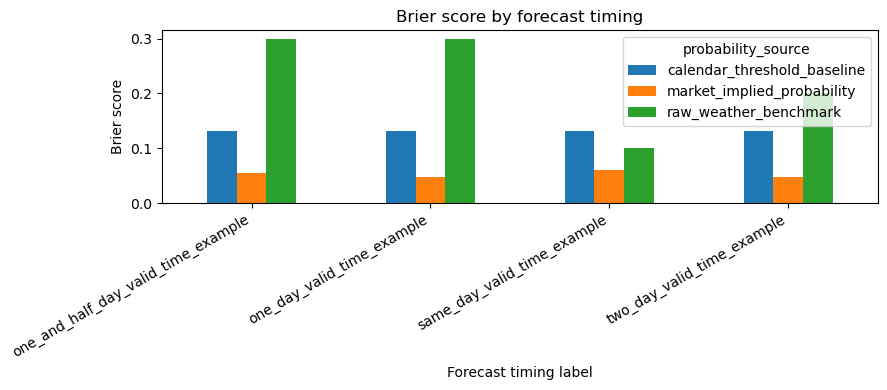

In [34]:
if not timing_scores_df.empty and "timing_label" in timing_scores_df.columns:
    timing_pivot_brier = timing_scores_df.pivot(
        index="timing_label",
        columns="probability_source",
        values="brier_score",
    ).reset_index()

    display(timing_pivot_brier)

    ax = timing_pivot_brier.plot(
        x="timing_label",
        kind="bar",
        figsize=(9, 4),
        title="Brier score by forecast timing",
    )
    ax.set_xlabel("Forecast timing label")
    ax.set_ylabel("Brier score")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

## 11. Calibration by threshold direction

The realised target changes from one to zero around the observed daily maximum temperature. This section makes that structure explicit by inspecting probabilities below and above the realised boundary.

In [37]:
boundary_summary_rows = []

realised_temperature = None
if "official_realised_temperature_c" in scoring_df.columns and scoring_df["official_realised_temperature_c"].notna().any():
    realised_temperature = float(scoring_df["official_realised_temperature_c"].dropna().iloc[0])

if realised_temperature is not None:
    scoring_df_boundary = scoring_df.copy()
    scoring_df_boundary["threshold_relation_to_realised_temp"] = np.where(
        scoring_df_boundary["threshold_c"] <= realised_temperature,
        "threshold_at_or_below_realised_temperature",
        "threshold_above_realised_temperature",
    )

    for relation, group in scoring_df_boundary.groupby("threshold_relation_to_realised_temp"):
        for source, col in available_sources.items():
            boundary_summary_rows.append({
                "threshold_relation_to_realised_temp": relation,
                "probability_source": source,
                "rows": group[[col, "realised_exceeds_threshold"]].dropna().shape[0],
                "event_rate": pd.to_numeric(group["realised_exceeds_threshold"], errors="coerce").mean(),
                "average_probability": pd.to_numeric(group[col], errors="coerce").mean(),
                "brier_score": brier_score(group["realised_exceeds_threshold"], group[col]),
                "log_score": log_score(group["realised_exceeds_threshold"], group[col]),
            })

boundary_scores_df = pd.DataFrame(boundary_summary_rows)
boundary_scores_df

,threshold_relation_to_realised_temp,probability_source,rows,event_rate,average_probability,brier_score,log_score
0,threshold_above_realised_temperature,market_implied_probability,4,0.0,0.119529,0.016174,0.128555
1,threshold_above_realised_temperature,calendar_threshold_baseline,4,0.0,0.110933,0.012306,0.117582
2,threshold_above_realised_temperature,raw_weather_benchmark,4,0.0,0.000000,0.000000,0.000001
3,threshold_at_or_below_realised_temperature,market_implied_probability,36,1.0,0.885070,0.057005,0.166752
4,threshold_at_or_below_realised_temperature,calendar_threshold_baseline,36,1.0,0.735200,0.144489,0.410747
5,threshold_at_or_below_realised_temperature,raw_weather_benchmark,36,1.0,0.750000,0.250000,3.453878


## 12. Save outputs

In [40]:
scores_output_path = PROCESSED_DIR / "hong_kong_probability_scoring_metrics.csv"
calibration_output_path = PROCESSED_DIR / "hong_kong_probability_calibration_table.csv"
threshold_scores_output_path = PROCESSED_DIR / "hong_kong_probability_scores_by_threshold.csv"
timing_scores_output_path = PROCESSED_DIR / "hong_kong_probability_scores_by_timing.csv"
boundary_scores_output_path = PROCESSED_DIR / "hong_kong_probability_scores_by_realised_boundary.csv"

scores_df.to_csv(scores_output_path, index=False)
calibration_df.to_csv(calibration_output_path, index=False)
threshold_scores_df.to_csv(threshold_scores_output_path, index=False)
timing_scores_df.to_csv(timing_scores_output_path, index=False)

if not boundary_scores_df.empty:
    boundary_scores_df.to_csv(boundary_scores_output_path, index=False)

print("Saved scoring metrics:", scores_output_path)
print("Saved calibration table:", calibration_output_path)
print("Saved threshold scores:", threshold_scores_output_path)
print("Saved timing scores:", timing_scores_output_path)

if not boundary_scores_df.empty:
    print("Saved boundary scores:", boundary_scores_output_path)

Saved scoring metrics: ../data/processed/probability_scoring_calibration/hong_kong_probability_scoring_metrics.csv
Saved calibration table: ../data/processed/probability_scoring_calibration/hong_kong_probability_calibration_table.csv
Saved threshold scores: ../data/processed/probability_scoring_calibration/hong_kong_probability_scores_by_threshold.csv
Saved timing scores: ../data/processed/probability_scoring_calibration/hong_kong_probability_scores_by_timing.csv
Saved boundary scores: ../data/processed/probability_scoring_calibration/hong_kong_probability_scores_by_realised_boundary.csv


## 13. Interpretation

This notebook provides the formal scoring and calibration diagnostics for the current Hong Kong prototype.

Brier score, log score and absolute error compare the probabilistic forecasts with the official realised threshold labels. Calibration tables compare predicted probabilities with realised frequencies across probability bins. The Brier decomposition terms provide a diagnostic separation between reliability, resolution and uncertainty, although this decomposition should be interpreted cautiously for the current small sample.

The results remain preliminary because the current data contain one realised event expanded across thresholds and forecast timings. The purpose of this notebook is therefore to validate the scoring pipeline and prepare the exact evaluation structure needed for a larger empirical sample.

For the dissertation, this workflow should be repeated after the dataset is expanded across more dates, cities and contracts. At that stage, calibration and score comparisons will become more meaningful and can support stronger statements about whether market-implied probabilities, raw weather forecasts or post-processed model probabilities are better calibrated.